## Setup

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, QuantileTransformer
from sklearn.utils.class_weight import compute_class_weight

In [2]:
DATA_DIR      = Path("/home/jupyter-iec2023se02/data/CSE-CIC-IDS2018/2018")
PROCESSED_DIR = Path("/home/jupyter-iec2023se02/data/1_processed/CSE-CIC-IDS2018")

RANDOM_STATE         = 42
TEST_SIZE            = 0.15
VAL_SIZE             = 0.15
BENIGN_CAP           = 950_000 
NEAR_CONSTANT_THRESH = 0.99999
CORRELATION_THRESH   = 0.99

DROP_COLS = ["Flow ID", "Src IP", "Src Port", "Dst IP", "Dst Port", "Timestamp"]
LABEL_COL = "Label"

# Dropped: label-corrupted or < 600 samples (baseline F1 < 0.35, unreliable)
LABELS_TO_DROP = [
    "Infilteration",              # label corruption — Liu et al. 2022 IEEE CNS
    "Brute Force -Web",           #  570 samples → F1=0.04
    "Brute Force -XSS",           #  229 samples → F1=0.16
    "DoS attacks-SlowHTTPTest",   #   55 samples → F1=0.30
    "FTP-BruteForce",             #   53 samples → F1=0.00
    "SQL Injection",              #   85 samples → F1=0.01
    "Label",                      # header artifact
]

CLASS_LIST = [
    "Benign",
    "Bot",
    "DDOS attack-HOIC",
    "DDOS attack-LOIC-UDP",
    "DDoS attacks-LOIC-HTTP",
    "DoS attacks-GoldenEye",
    "DoS attacks-Hulk",
    "DoS attacks-Slowloris",
    "SSH-Bruteforce",
]
NUM_CLASSES = len(CLASS_LIST)

CSV_FILES = sorted(DATA_DIR.glob("*.csv"))
assert CSV_FILES, f"No CSV files found in {DATA_DIR}"
print(f"Found {len(CSV_FILES)} CSV files  |  {NUM_CLASSES} classes")

Found 10 CSV files  |  9 classes


## 1. Raw Data Quality

In [3]:
rows = []
for path in CSV_FILES:
    df_tmp = pd.read_csv(path, low_memory=False)
    df_tmp.columns = [c.strip() for c in df_tmp.columns]
    num = df_tmp.select_dtypes(include=[np.number])
    rows.append({
        "file":       path.name,
        "rows":       len(df_tmp),
        "duplicates": int(df_tmp.duplicated().sum()),
        "missing":    int(df_tmp.isna().sum().sum()),
        "inf":        int(np.isinf(num.to_numpy()).sum()) if not num.empty else 0,
        "n_labels":   int(df_tmp[LABEL_COL].nunique()) if LABEL_COL in df_tmp.columns else 0,
    })
    del df_tmp

qdf = pd.DataFrame(rows)
print(qdf.to_string(index=False))
print(f"\nTotal rows: {qdf['rows'].sum():,}  |  "
      f"duplicates: {qdf['duplicates'].sum():,}  |  inf: {qdf['inf'].sum():,}")

                                              file    rows  duplicates  missing   inf  n_labels
   Friday-02-03-2018_TrafficForML_CICFlowMeter.csv 1048575        5459     2558  5542         2
   Friday-16-02-2018_TrafficForML_CICFlowMeter.csv 1048575      147586        0     0         4
   Friday-23-02-2018_TrafficForML_CICFlowMeter.csv 1048575        2614     3754  7662         4
 Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv  331125          97     1834     0         3
 Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv 1048575        2421     4921 11133         3
 Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv 1048575        3278     3569  7651         4
  Tuesday-20-02-2018_TrafficForML_CICFlowMeter.csv 7948748           2    36767 82139         2
Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv 1048575      225628     2277  5371         3
Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv 1048575       17557        0     0         3
Wednesday-28-02-2018_TrafficForML_CICFlo

## 2. Load, Clean & Filter

In [4]:
def clean_file(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False)
    df.columns = [c.strip() for c in df.columns]
    df = df.drop(columns=DROP_COLS, errors="ignore").drop_duplicates()
    for col in df.columns:
        if col != LABEL_COL:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)


frames = {}
for path in CSV_FILES:
    frames[path.name] = clean_file(path)

# Drop unwanted labels
for name, df in frames.items():
    df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip()
    mask = df[LABEL_COL].isin(LABELS_TO_DROP)
    if mask.any():
        print(f"  {name}: drop {mask.sum():,} → {df.loc[mask, LABEL_COL].value_counts().to_dict()}")
    frames[name] = df.loc[~mask].reset_index(drop=True)

df_all = pd.concat(frames.values(), ignore_index=True)
print(f"\nAfter cleaning & filtering: {len(df_all):,} rows × {df_all.shape[1]} cols")

dist = df_all[LABEL_COL].value_counts()
print("\nClass distribution:")
for cls in CLASS_LIST:
    n = dist.get(cls, 0)
    print(f"  {cls:30s}: {n:>9,}  ({100*n/len(df_all):5.1f}%)")

  Friday-16-02-2018_TrafficForML_CICFlowMeter.csv: drop 55 → {'DoS attacks-SlowHTTPTest': 55}
  Friday-23-02-2018_TrafficForML_CICFlowMeter.csv: drop 543 → {'Brute Force -Web': 342, 'Brute Force -XSS': 150, 'SQL Injection': 51}
  Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv: drop 62,034 → {'Infilteration': 62034}
  Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv: drop 341 → {'Brute Force -Web': 228, 'Brute Force -XSS': 79, 'SQL Injection': 34}
  Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv: drop 53 → {'FTP-BruteForce': 53}
  Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv: drop 56,449 → {'Infilteration': 56449}

After cleaning & filtering: 11,022,250 rows × 78 cols

Class distribution:
  Benign                        : 9,811,199  ( 89.0%)
  Bot                           :   144,535  (  1.3%)
  DDOS attack-HOIC              :   198,861  (  1.8%)
  DDOS attack-LOIC-UDP          :     1,730  (  0.0%)
  DDoS attacks-LOIC-HTTP        :   575,364  (  5.2%)
  DoS attacks-Golde

## 3. Feature Selection

In [5]:
X = df_all.drop(columns=[LABEL_COL]).copy()
y = df_all[LABEL_COL].copy()
print(f"Starting features: {X.shape[1]}")

# Step 1: near-constant
drop1 = [c for c in X if X[c].value_counts(normalize=True, dropna=False).iloc[0] > NEAR_CONSTANT_THRESH]
X = X.drop(columns=drop1)
print(f"  Step 1 — near-constant   dropped ({len(drop1)}): {drop1}")

# Step 2: duplicate-value columns
seen, drop2 = {}, []
for col, h in {c: pd.util.hash_pandas_object(X[c]).sum() for c in X}.items():
    if h in seen and X[col].equals(X[seen[h]]): drop2.append(col)
    else: seen[h] = col
X = X.drop(columns=drop2)
print(f"  Step 2 — duplicate-value dropped ({len(drop2)}): {drop2}")

# Step 3: high Pearson correlation
print(f"  Step 3 — correlation matrix ({X.shape[1]} × {len(X):,})…")
upper = X.corr(numeric_only=True).abs().where(
    np.triu(np.ones((X.shape[1],) * 2), k=1).astype(bool))
drop3 = [c for c in upper if (upper[c] > CORRELATION_THRESH).any()]
X = X.drop(columns=drop3)
print(f"  Step 3 — high-corr>0.99  dropped ({len(drop3)}): {drop3}")

FEATURE_NAMES = list(X.columns)
print(f"\nFinal: {len(FEATURE_NAMES)} features")

Starting features: 77
  Step 1 — near-constant   dropped (8): ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']
  Step 2 — duplicate-value dropped (5): ['SYN Flag Cnt', 'CWE Flag Count', 'Subflow Fwd Pkts', 'Subflow Fwd Byts', 'Subflow Bwd Pkts']
  Step 3 — correlation matrix (64 × 11,022,250)…
  Step 3 — high-corr>0.99  dropped (15): ['TotLen Bwd Pkts', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Fwd Header Len', 'Bwd Header Len', 'ECE Flag Cnt', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Subflow Bwd Byts', 'Fwd Act Data Pkts', 'Idle Max']

Final: 49 features


## 4. Split / Scale / Encode

In [6]:
VAL_FRAC = VAL_SIZE / (1 - TEST_SIZE)

X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=VAL_FRAC, stratify=y_tv, random_state=RANDOM_STATE)

# Cap Benign only in train — val/test keep natural distribution
n_cap = min(BENIGN_CAP, (y_train == "Benign").sum())
keep_idx = (y_train[y_train == "Benign"].sample(n=n_cap, random_state=RANDOM_STATE).index
            .union(y_train[y_train != "Benign"].index))
X_train = X_train.loc[keep_idx].sample(frac=1, random_state=RANDOM_STATE)
y_train = y_train.loc[X_train.index]

print(f"train {len(X_train):,}  (Benign {(y_train=='Benign').sum():,}, {100*(y_train=='Benign').mean():.1f}%)")
print(f"val   {len(X_val):,}  (Benign {(y_val=='Benign').sum():,}, {100*(y_val=='Benign').mean():.1f}%)")
print(f"test  {len(X_test):,}  (Benign {(y_test=='Benign').sum():,}, {100*(y_test=='Benign').mean():.1f}%)")

scaler = Pipeline([
    ("qt", QuantileTransformer(output_distribution="normal", n_quantiles=1_000,
                               random_state=RANDOM_STATE, subsample=int(1e8))),
    ("mm", MinMaxScaler()),
])
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURE_NAMES, index=X_train.index)
X_val_s   = pd.DataFrame(scaler.transform(X_val),       columns=FEATURE_NAMES, index=X_val.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=FEATURE_NAMES, index=X_test.index)
print(f"Scaled range: [{X_train_s.min().min():.3f}, {X_train_s.max().max():.3f}]")

le = LabelEncoder()
le.fit(CLASS_LIST)
y_train_enc = le.transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

class_weights = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=y_train_enc)
tbl = pd.DataFrame({
    "class":   le.classes_,
    "train_n": [(y_train_enc == i).sum() for i in range(NUM_CLASSES)],
    "pct":     [f"{100*(y_train_enc==i).sum()/len(y_train_enc):.2f}%" for i in range(NUM_CLASSES)],
    "weight":  class_weights.round(2),
})
print("\n" + tbl.to_string(index=False))

train 1,797,735  (Benign 950,000, 52.8%)
val   1,653,338  (Benign 1,471,680, 89.0%)
test  1,653,338  (Benign 1,471,680, 89.0%)
Scaled range: [0.000, 1.000]

                 class  train_n    pct  weight
                Benign   950000 52.84%    0.21
                   Bot   101175  5.63%    1.97
      DDOS attack-HOIC   139203  7.74%    1.43
  DDOS attack-LOIC-UDP     1210  0.07%  165.08
DDoS attacks-LOIC-HTTP   402754 22.40%    0.50
 DoS attacks-GoldenEye    28984  1.61%    6.89
      DoS attacks-Hulk   101639  5.65%    1.97
 DoS attacks-Slowloris     6936  0.39%   28.80
        SSH-Bruteforce    65834  3.66%    3.03


## 5. Sanity Check

In [7]:
for name, Xs, ye in [("train", X_train_s, y_train_enc),
                     ("val",   X_val_s,   y_val_enc),
                     ("test",  X_test_s,  y_test_enc)]:
    n_nan = int(Xs.isna().sum().sum())
    n_inf = int(np.isinf(Xs.to_numpy()).sum())
    missing = [le.classes_[i] for i in range(NUM_CLASSES) if (ye == i).sum() == 0]
    tag = "OK" if n_nan == 0 and n_inf == 0 and not missing else "FAIL"
    print(f"  [{tag}] {name:5s}  shape={Xs.shape}  NaN={n_nan}  inf={n_inf}"
          + (f"  missing={missing}" if missing else ""))

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
LABEL_ENC_COL = "label_encoded"
for split, Xs, ye in [("train", X_train_s, y_train_enc),
                      ("val",   X_val_s,   y_val_enc),
                      ("test",  X_test_s,  y_test_enc)]:
    Xs.astype("float32").to_csv(PROCESSED_DIR / f"X_{split}.csv", index=False)
    pd.DataFrame({LABEL_ENC_COL: ye}).to_csv(PROCESSED_DIR / f"y_{split}.csv", index=False)

  [OK] train  shape=(1797735, 49)  NaN=0  inf=0
  [OK] val    shape=(1653338, 49)  NaN=0  inf=0
  [OK] test   shape=(1653338, 49)  NaN=0  inf=0


## 6. MLP Baseline

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


def to_tensor(Xdf, yarr):
    return (torch.tensor(Xdf.to_numpy(), dtype=torch.float32),
            torch.tensor(yarr, dtype=torch.long))

X_tr_t, y_tr_t = to_tensor(X_train_s, y_train_enc)
X_va_t, y_va_t = to_tensor(X_val_s,   y_val_enc)
X_te_t, y_te_t = to_tensor(X_test_s,  y_test_enc)

BATCH = 4096
train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=BATCH,   shuffle=True,  num_workers=0, pin_memory=(device.type == "cuda"))
val_loader   = DataLoader(TensorDataset(X_va_t, y_va_t), batch_size=BATCH*4, shuffle=False, num_workers=0)


class MLP(nn.Module):
    def __init__(self, in_dim, hidden, out_dim, p=0.3):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(p)]
            prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


model     = MLP(X_tr_t.shape[1], [256, 128, 64], NUM_CLASSES).to(device)
cw_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=cw_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

print(model)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Device: cuda
MLP(
  (net): Sequential(
    (0): Linear(in_features=49, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=9, bias=True)
  )
)
Trainable params: 55,433


Epoch 01/20  train=0.1898  val_loss=0.0416  val_f1=0.8478 ←
Epoch 02/20  train=0.0228  val_loss=0.0314  val_f1=0.8666 ←
Epoch 03/20  train=0.0167  val_loss=0.0261  val_f1=0.8821 ←
Epoch 04/20  train=0.0139  val_loss=0.0248  val_f1=0.8854 ←
Epoch 05/20  train=0.0121  val_loss=0.0216  val_f1=0.9126 ←
Epoch 06/20  train=0.0114  val_loss=0.0209  val_f1=0.9096
Epoch 07/20  train=0.0103  val_loss=0.0195  val_f1=0.9156 ←
Epoch 08/20  train=0.0096  val_loss=0.0182  val_f1=0.9185 ←
Epoch 09/20  train=0.0095  val_loss=0.0167  val_f1=0.9273 ←
Epoch 10/20  train=0.0087  val_loss=0.0154  val_f1=0.9226
Epoch 11/20  train=0.0081  val_loss=0.0152  val_f1=0.9196
Epoch 12/20  train=0.0077  val_loss=0.0151  val_f1=0.9257
Epoch 13/20  train=0.0076  val_loss=0.0131  val_f1=0.9265
Epoch 14/20  train=0.0068  val_loss=0.0128  val_f1=0.9315 ←
Epoch 15/20  train=0.0066  val_loss=0.0119  val_f1=0.9332 ←
Epoch 16/20  train=0.0062  val_loss=0.0113  val_f1=0.9362 ←
Epoch 17/20  train=0.0060  val_loss=0.0114  val_f1

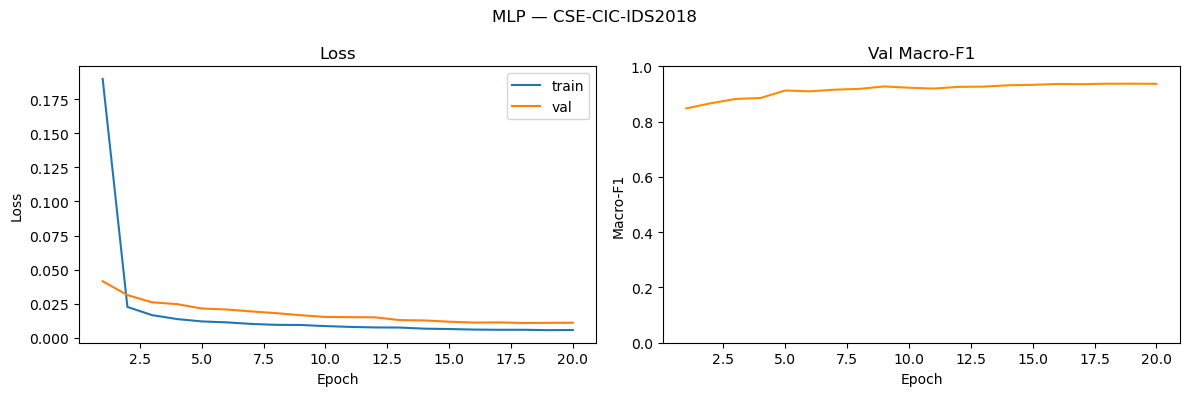

In [9]:
def _eval(model, loader):
    model.eval()
    loss_sum, preds_all, labels_all = 0.0, [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            loss_sum += criterion(logits, yb).item() * len(yb)
            preds_all.extend(logits.argmax(1).cpu().tolist())
            labels_all.extend(yb.cpu().tolist())
    mf1 = f1_score(labels_all, preds_all, average="macro", zero_division=0)
    return loss_sum / len(labels_all), mf1


MAX_EPOCHS, PATIENCE = 20, 5
history = {"train_loss": [], "val_loss": [], "val_f1": []}
best_f1, no_imp, best_state = 0.0, 0, None

for ep in range(1, MAX_EPOCHS + 1):
    model.train()
    run = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward(); optimizer.step()
        run += loss.item() * len(yb)
    scheduler.step()

    tl = run / len(y_tr_t)
    vl, vf1 = _eval(model, val_loader)
    history["train_loss"].append(tl); history["val_loss"].append(vl); history["val_f1"].append(vf1)

    imp = vf1 > best_f1 + 1e-5
    if imp: best_f1, no_imp, best_state = vf1, 0, {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:   no_imp += 1

    print(f"Epoch {ep:02d}/{MAX_EPOCHS}  train={tl:.4f}  val_loss={vl:.4f}  val_f1={vf1:.4f}" + (" ←" if imp else ""))
    if no_imp >= PATIENCE:
        print(f"\nEarly stop at epoch {ep}.")
        break

model.load_state_dict(best_state)
print(f"\nBest val_macro_f1 = {best_f1:.4f}")

eps = range(1, len(history["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(eps, history["train_loss"], label="train"); ax1.plot(eps, history["val_loss"], label="val")
ax1.set(xlabel="Epoch", ylabel="Loss", title="Loss"); ax1.legend()
ax2.plot(eps, history["val_f1"], color="darkorange")
ax2.set(xlabel="Epoch", ylabel="Macro-F1", title="Val Macro-F1", ylim=[0, 1])
plt.suptitle("MLP — CSE-CIC-IDS2018"); plt.tight_layout(); plt.show()

## 7. Test Evaluation

TEST SET — Classification Report
                        precision    recall  f1-score   support

                Benign     1.0000    0.9950    0.9975   1471680
                   Bot     0.9070    0.9991    0.9508     21680
      DDOS attack-HOIC     0.9244    0.9990    0.9603     29829
  DDOS attack-LOIC-UDP     0.7263    1.0000    0.8414       260
DDoS attacks-LOIC-HTTP     0.9902    0.9986    0.9944     86305
 DoS attacks-GoldenEye     0.9846    0.9998    0.9922      6211
      DoS attacks-Hulk     0.9858    1.0000    0.9928     21780
 DoS attacks-Slowloris     0.5275    0.9993    0.6905      1486
        SSH-Bruteforce     0.9937    1.0000    0.9968     14107

              accuracy                         0.9955   1653338
             macro avg     0.8933    0.9990    0.9352   1653338
          weighted avg     0.9961    0.9955    0.9956   1653338



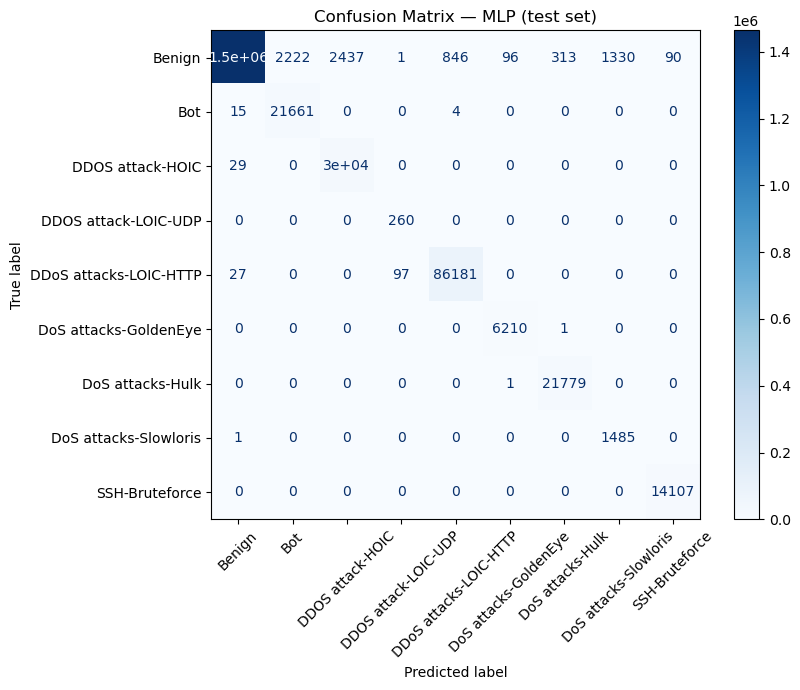


Macro-F1: 0.9352  ✓ PASS

Per-class F1:
  Benign                        : 0.9975  ███████████████████
  Bot                           : 0.9508  ███████████████████
  DDOS attack-HOIC              : 0.9603  ███████████████████
  DDOS attack-LOIC-UDP          : 0.8414  ████████████████
  DDoS attacks-LOIC-HTTP        : 0.9944  ███████████████████
  DoS attacks-GoldenEye         : 0.9922  ███████████████████
  DoS attacks-Hulk              : 0.9928  ███████████████████
  DoS attacks-Slowloris         : 0.6905  █████████████
  SSH-Bruteforce                : 0.9968  ███████████████████


In [10]:
test_loader = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=BATCH * 4, shuffle=False)
model.eval()
preds, labels = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        preds.extend(model(Xb.to(device)).argmax(1).cpu().tolist())
        labels.extend(yb.tolist())
preds, labels = np.array(preds), np.array(labels)

print("=" * 60)
print("TEST SET — Classification Report")
print("=" * 60)
print(classification_report(labels, preds, target_names=le.classes_, digits=4))

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(confusion_matrix(labels, preds), display_labels=le.classes_).plot(
    ax=ax, colorbar=True, cmap="Blues", xticks_rotation=45)
ax.set_title("Confusion Matrix — MLP (test set)"); plt.tight_layout(); plt.show()

macro_f1     = f1_score(labels, preds, average="macro")
per_class_f1 = f1_score(labels, preds, average=None)
print(f"\nMacro-F1: {macro_f1:.4f}  {'✓ PASS' if macro_f1 >= 0.80 else '✗ FAIL  (target ≥ 0.80)'}")
print("\nPer-class F1:")
for i, cls in enumerate(le.classes_):
    bar = "█" * int(per_class_f1[i] * 20)
    print(f"  {cls:30s}: {per_class_f1[i]:.4f}  {bar}")